# Models for Outcomes

In [23]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import shap
import numpy as np
from itertools import product

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
load_path = '../data/catalog/train.csv'
train_data = pd.read_csv(load_path, index_col='Label')

## PCA

In [13]:
x_vars = ['max_IWV_ais', 'max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'max_landfalling_omega500', 'cumulative_landfalling_area', 'max_south_extent']
snow_var = 'cumulative_snowfall_ais'
rain_var = 'cumulative_rainfall_ais'
temp_var = 'max_T2m_ais'

X = train_data[x_vars]
y = train_data[snow_var]
x_and_y = X.copy()
x_and_y['snow'] = y

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_and_y)

In [20]:
pca = PCA(n_components=7)
pca.fit(X_scaled)

PCA(n_components=7)

In [21]:
pca.explained_variance_ratio_

array([0.37217315, 0.23828728, 0.13227198, 0.09792291, 0.08636802,
       0.05793149, 0.01504517])

In [22]:
pca.components_

array([[ 0.34495678, -0.0468697 ,  0.1780816 ,  0.09158191,  0.55707916,
        -0.4339119 ,  0.58317324],
       [-0.18626465,  0.60967768,  0.56007809,  0.49026003,  0.03116197,
         0.19467103,  0.02623664],
       [ 0.67710858, -0.32725548,  0.02077838,  0.52537605, -0.20555834,
         0.33248901, -0.07192296],
       [-0.44860585, -0.31966546, -0.20410596,  0.65247383, -0.03102314,
        -0.46350281, -0.11570716],
       [-0.0214633 , -0.42557308,  0.76914773, -0.22173248, -0.26951531,
        -0.27617619, -0.16959235],
       [-0.40724788, -0.48543111,  0.13321801,  0.01732869,  0.39084242,
         0.60903528,  0.23827863],
       [-0.14239222, -0.00764173, -0.05633136,  0.0070845 , -0.64813484,
         0.0352504 ,  0.74506462]])

In [26]:
X = train_data[x_vars]
y = train_data[temp_var]
x_and_y = X.copy()
x_and_y['temp'] = y

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x_and_y)

pca = PCA(n_components=7)
pca.fit(X_scaled)

PCA(n_components=7)

In [27]:
pca.explained_variance_ratio_

array([0.33540769, 0.23803375, 0.15724872, 0.10006506, 0.08289469,
       0.05602644, 0.03032364])

In [28]:
pca.components_

array([[ 0.52851937, -0.28490025,  0.01602342,  0.00131437,  0.40916942,
        -0.40414989,  0.55541326],
       [ 0.00524552,  0.51896735,  0.61266792,  0.5082903 ,  0.30121738,
        -0.07193165, -0.03191076],
       [ 0.41554875, -0.05063129,  0.05326411,  0.35787731, -0.45015337,
         0.60733896,  0.34977679],
       [-0.22584236, -0.3923158 , -0.33446626,  0.7769226 , -0.02395811,
        -0.24448833, -0.13877538],
       [-0.18488772, -0.55165384,  0.70255541, -0.09873695, -0.35268822,
        -0.18377038, -0.00096988],
       [-0.03747648, -0.4308163 ,  0.12135929, -0.01258256,  0.63338535,
         0.5872983 , -0.22805731],
       [-0.67923947,  0.05572144, -0.03693698, -0.00685891,  0.11432605,
         0.15544358,  0.70490022]])

## Non-extreme outcomes

For modelling relationships between covariates and the average of the outcome variable among all ARs, we use the `xgboost` algorithm and assess variable importance via partial dependence plots at SHAP values.

In [43]:
# some basic cross validation
# for snowfall
etas = np.linspace(0,1,11)
# units of Y are in gigatons, a loss of 1 will be really
# high, so that seems like a reasonable upper bound
gammas = np.linspace(0,1,20)
# intuition tells me we won't need to go THAT deep
max_depth = np.arange(10) + 1
# don't have a great intuition on this, mostly testing
lambdas = np.linspace(0, 10, 11)
# same
min_child_weights = np.linspace(0, 10, 11)

# since we're doing early stopping, this should be good
nrounds = 100
early_stopping_rounds = 5

tree_method = 'exact'
booster = 'gbtree'

In [44]:
hyperparams_lst = list(product(etas, gammas, max_depth, lambdas, min_child_weights))


In [45]:
dtrain = xgb.DMatrix(X, label=train_data[snow_var])
param_set = hyperparams_lst[0]
params = dict(booster='gbtree',
                   eta=param_set[0],
                   gamma=param_set[1],
                   max_depth=param_set[2],
                   reg_lambda=param_set[3],
                   min_child_weight=param_set[4],
                   tree_method=tree_method)

In [56]:
res = xgb.cv(params,
       dtrain,
       nrounds,
       nfold=10,
       seed=12345,
       early_stopping_rounds=early_stopping_rounds)

30 ms ± 424 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [57]:
res

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,0.624098,0.012638,0.622707,0.050089


In [106]:
model = xgb.XGBRegressor(n_estimators=10, max_depth=5).fit(X, train_data[snow_var])

In [107]:
explainer_xgb = shap.Explainer(model, X)
shap_values_xgb = explainer_xgb(X)

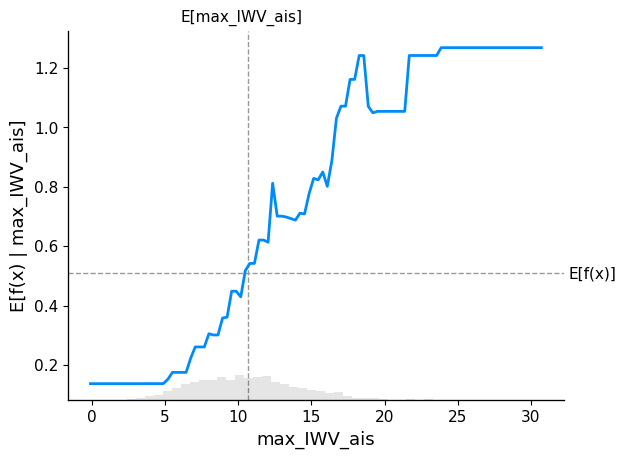

In [108]:
fig, ax = shap.partial_dependence_plot(
    'max_IWV_ais',
    model.predict,
    X,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

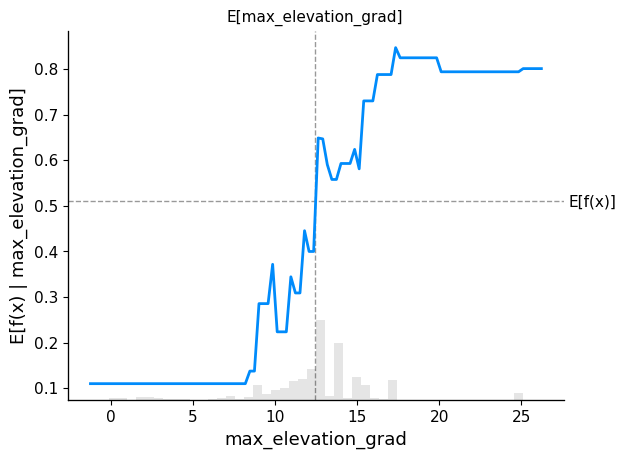

In [109]:
fig, ax = shap.partial_dependence_plot(
    'max_elevation_grad',
    model.predict,
    X,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

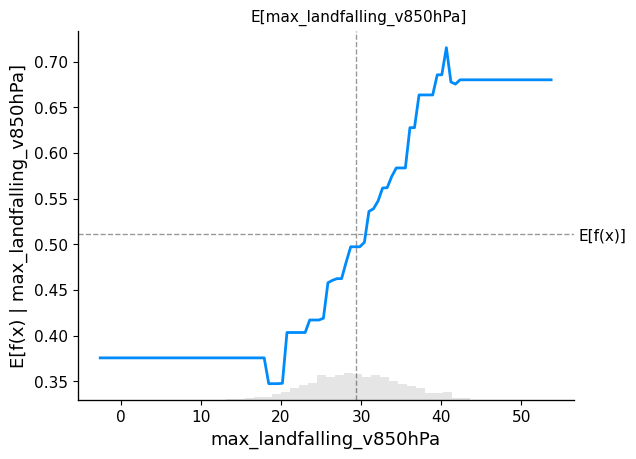

In [112]:
fig, ax = shap.partial_dependence_plot(
    'max_landfalling_v850hPa',
    model.predict,
    X,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

In [111]:
np.sum(np.abs(shap_values_xgb.values), axis = 0)

array([547.53652767,  56.58213787, 189.70436756,  31.11019269,
       399.86203468])